# 🤖 멋진 챗봇 만들기 — 개선 버전

> **AIFFEL Quest ENG · NLP02**  
> Transformer 기반 한국어 챗봇 구현 + Pre-LN final_norm 버그 수정

---

## 📋 개선 사항 요약

| # | 개선 내용 | 효과 |
|---|---|---|
| 1 | 중복 제거 완화 | 데이터 약 3.3만 → 루브릭 '3만 가량' 충족 |
| 2 | 패딩 마스크 수정 (`supports_masking=True`) | 어텐션이 `<pad>` 토큰 무시 |
| 3 | **Pre-LN `final_norm` 추가** | 모드 붕괴 방지 → 답변 품질 향상 |

---

## 🐛 핵심 버그 수정 — Pre-LN final_norm

### 문제 발생 원인

```
Pre-LN 구조에서 residual connection 누적
    ↓
Encoder/Decoder 출력 norm 폭주
    ↓
cross-attention의 Q·K^T 값이 극단적으로 커짐
    ↓
softmax가 한 위치에 100% 집중 → 모드 붕괴(Mode Collapse)
    ↓
답변이 단조롭게 반복되는 현상 발생
```

> **모드 붕괴(Mode Collapse)**: 모델이 훈련 데이터의 다양한 패턴을 무시하고 극히 제한적이거나 단조로운 결과물만 반복 생성하는 오류 — 김민욱 검색 붙임

### 해결 방법

Encoder/Decoder 클래스 끝에 `final_norm` 한 줄씩 추가, `forward` 끝에서 통과시키는 것.  
뭔가 대단한 걸 추가한 게 아니라, **이게 그냥 Pre-LN 표준 구조** — 있어야 할 게 없어서 생긴 일.

---

## 🗺️ 전체 진행 과정

```
Step 1. 데이터 로드
Step 2. Kiwi 토크나이저
Step 3. 데이터 정제 + 토큰화 (중복 제거 완화)
Step 4. 데이터 증강 (Lexical Substitution, 3배 → 약 3.3만)
Step 5. 벡터화 (<start>/<end> + 공유 단어사전)
Step 6. Transformer 정의 (Pre-LN final_norm 수정)
Step 7. 학습 (Warmup Scheduler + Masked Loss)
Step 8. 예문 답변 생성
Step 9. BLEU 평가
```

---

## ⚙️ Step 1. 라이브러리 설치

- `kiwipiepy`: MeCab 없이 사용 가능한 한국어 형태소 분석기
- `gensim`: Word2Vec 기반 데이터 증강용

In [ ]:
!pip install -q kiwipiepy gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.0 MB/s eta 0:00:00


---

## 📥 Step 2. 데이터 로드

- **데이터셋**: [songys/Chatbot_data](https://github.com/songys/Chatbot_data)
- jsDelivr CDN 미러 사용 → 429 오류 / 빈 파일 회피

In [ ]:
# Step 1. 데이터 로드 (jsDelivr 미러 → 429/빈파일 회피)
import pandas as pd
url = 'https://cdn.jsdelivr.net/gh/songys/Chatbot_data@master/ChatbotData.csv'
data = pd.read_csv(url)
questions = list(data['Q'])
answers   = list(data['A'])
print("원본:", len(questions))

원본: 11823


---

## 🔤 Step 3. Kiwi 토크나이저

- MeCab 대신 **Kiwi** 사용 (Colab 설치 간단)
- 형태소 단위로 분리해서 토큰화

In [ ]:
# Step 2. Kiwi 토크나이저 (MeCab 대체, 설치 간단)
from kiwipiepy import Kiwi
kiwi = Kiwi()
def kiwi_morphs(sentence):
    return [t.form for t in kiwi.tokenize(sentence)]
print(kiwi_morphs("안녕하세요 반갑습니다"))

['안녕', '하', '세요', '반갑', '습니다']


---

## 🧹 Step 4. 데이터 정제 + 토큰화

### 개선 포인트 ✅
- **기존**: 질문이 동일한 쌍 제거 → 데이터 손실 과다
- **개선**: 완전히 동일한 (질문, 답변) 쌍만 제거 → 더 많은 데이터 확보

| 항목 | 내용 |
|---|---|
| 소문자 변환 | `sentence.lower()` |
| 특수문자 제거 | 한글/영문/숫자/문장부호만 유지 |
| 최대 길이 | 40 토큰 이하만 선별 |

In [ ]:
# Step 3. 정제 + 토큰화  (중복 제거 완화: 완전 동일한 (질문,답변) 쌍만 제거)
import re
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"[^가-힣a-z0-9?.!,]+", " ", sentence)
    return sentence.strip()

def build_corpus(src_data, tgt_data, tokenizer, max_len=40):
    src_corpus, tgt_corpus = [], []
    seen = set()
    for src, tgt in zip(src_data, tgt_data):
        src_p, tgt_p = preprocess_sentence(src), preprocess_sentence(tgt)
        key = (src_p, tgt_p)
        if key in seen:            # 완전 동일한 쌍만 제거 (데이터 더 확보)
            continue
        src_tok, tgt_tok = tokenizer(src_p), tokenizer(tgt_p)
        if len(src_tok) > max_len or len(tgt_tok) > max_len:
            continue
        seen.add(key)
        src_corpus.append(src_tok); tgt_corpus.append(tgt_tok)
    return src_corpus, tgt_corpus

que_corpus, ans_corpus = build_corpus(questions, answers, kiwi_morphs)
print("중복 제거 후:", len(que_corpus), '|', que_corpus[0], '→', ans_corpus[0])

중복 제거 후: 11747 | ['12', '시', '땡', '!'] → ['하루', '가', '또', '가', '네요', '.']


---

## 📊 Step 5. 데이터 증강 (Lexical Substitution)

- **Word2Vec** 기반 유사 단어 치환 (유사도 threshold=0.7)
- 원본 데이터를 **3배** 증강

```
원본 (1.1만)  +  질문 증강 (1.1만)  +  답변 증강 (1.1만)  =  약 3.3만
```

In [ ]:
# Step 4. 데이터 증강 (Lexical Substitution) → 3배 (약 3.3만)
from gensim.models import Word2Vec
import random
w2v = Word2Vec(sentences=que_corpus + ans_corpus, vector_size=100, window=5, min_count=1, sg=1, workers=4)

def lexical_sub(tokens, model, threshold=0.7):
    aug = tokens.copy()
    cand = [i for i, t in enumerate(aug) if t in model.wv]
    if not cand: return aug
    idx = random.choice(cand)
    sims = model.wv.most_similar(aug[idx], topn=1)
    if sims and sims[0][1] >= threshold: aug[idx] = sims[0][0]
    return aug

que_aug = [lexical_sub(q, w2v) for q in que_corpus]
ans_aug = [lexical_sub(a, w2v) for a in ans_corpus]
src_corpus = que_corpus + que_aug   + que_corpus
tgt_corpus = ans_corpus + ans_corpus + ans_aug
print("증강 후:", len(src_corpus), len(tgt_corpus))

증강 후: 35241 35241


---

## 🔢 Step 6. 벡터화

- 특수 토큰: `<start>`, `<end>`, `<unk>`
- 인코더/디코더 **공유 단어사전** 사용
- `post` 패딩으로 시퀀스 길이 통일

In [ ]:
# Step 5. 벡터화 (<start>/<end> + 공유 단어사전)
import tensorflow as tf
tgt_corpus = [a if a and a[0]=='<start>' else ['<start>']+a+['<end>'] for a in tgt_corpus]
tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='', oov_token='<unk>')
tokenizer.fit_on_texts(src_corpus + tgt_corpus)
enc_train = tokenizer.texts_to_sequences(src_corpus)
dec_train = tokenizer.texts_to_sequences(tgt_corpus)
enc_train = tf.keras.preprocessing.sequence.pad_sequences(enc_train, padding='post')
dec_train = tf.keras.preprocessing.sequence.pad_sequences(dec_train, padding='post')
VOCAB_SIZE = len(tokenizer.index_word) + 1
print("어휘:", VOCAB_SIZE, "| enc:", enc_train.shape, "| dec:", dec_train.shape)

어휘: 4992 | enc: (35241, 31) | dec: (35241, 42)


---

## 🏗️ Step 7. Transformer 정의

### 구성 요소

| 클래스 | 역할 |
|---|---|
| `PositionalEmbedding` | 위치 정보 임베딩 (sin/cos) |
| `FF` | Feed-Forward Network + Add & Norm |
| `EncLayer` | Self-Attention + FFN |
| `DecLayer` | Masked Self-Attention + Cross-Attention + FFN |
| `Transformer` | 전체 모델 통합 |

### ✅ 핵심 수정 (Pre-LN final_norm)

```python
# __init__ 에 추가
s.enc_final_norm = LayerNormalization(epsilon=1e-6)  # Encoder 스택 끝
s.dec_final_norm = LayerNormalization(epsilon=1e-6)  # Decoder 스택 끝

# call 에 추가
ctx = s.enc_final_norm(ctx)  # ← residual 누적 폭주 방지
x   = s.dec_final_norm(x)    # ← softmax 모드 붕괴 방지 핵심
```

In [ ]:
# Step 6. Transformer 정의
# [수정] Pre-LN final_norm 추가
# - 문제: Encoder/Decoder 스택 마지막 출력에 LayerNorm 누락
# - 원인: residual connection 누적 → 출력 norm 폭주 → cross-attention Q·K^T 극단적 증가
#         → softmax 모드 붕괴 (한 위치에 100% attention 집중, 답변 단조로워짐)
# - 해결: Encoder / Decoder 클래스 끝에 self.final_norm = LayerNormalization() 추가
#         forward 마지막에 out = self.final_norm(out) 통과 → Pre-LN 표준 구조 완성
import tensorflow as tf, numpy as np

def positional_encoding(length, depth):
    d=depth/2; pos=np.arange(length)[:,None]; dep=np.arange(d)[None,:]/d
    ang=pos*(1/(10000**dep))
    return tf.cast(np.concatenate([np.sin(ang),np.cos(ang)],-1),tf.float32)

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(s,vocab,d):
        super().__init__(); s.d=d
        s.emb=tf.keras.layers.Embedding(vocab,d,mask_zero=True)
        s.pe=positional_encoding(2048,d)
    def compute_mask(s,*a,**k): return s.emb.compute_mask(*a,**k)
    def call(s,x):
        L=tf.shape(x)[1]; x=s.emb(x)*tf.math.sqrt(tf.cast(s.d,tf.float32))
        return x+s.pe[None,:L,:]

class FF(tf.keras.layers.Layer):
    def __init__(s,d,dff,dr):
        super().__init__(); s.supports_masking=True
        s.seq=tf.keras.Sequential([tf.keras.layers.Dense(dff,activation='relu'),tf.keras.layers.Dense(d),tf.keras.layers.Dropout(dr)])
        s.add=tf.keras.layers.Add(); s.ln=tf.keras.layers.LayerNormalization()
    def call(s,x): return s.ln(s.add([x,s.seq(x)]))

def mha(nh,d,dr): return tf.keras.layers.MultiHeadAttention(num_heads=nh,key_dim=d//nh,dropout=dr)

class EncLayer(tf.keras.layers.Layer):
    def __init__(s,d,nh,dff,dr):
        super().__init__(); s.supports_masking=True
        s.a=mha(nh,d,dr); s.add=tf.keras.layers.Add(); s.ln=tf.keras.layers.LayerNormalization(); s.ff=FF(d,dff,dr)
    def call(s,x): x=s.ln(s.add([x,s.a(x,x,x)])); return s.ff(x)

class DecLayer(tf.keras.layers.Layer):
    def __init__(s,d,nh,dff,dr):
        super().__init__(); s.supports_masking=True
        s.sa=mha(nh,d,dr); s.ca=mha(nh,d,dr)
        s.a1=tf.keras.layers.Add(); s.a2=tf.keras.layers.Add()
        s.l1=tf.keras.layers.LayerNormalization(); s.l2=tf.keras.layers.LayerNormalization(); s.ff=FF(d,dff,dr)
    def call(s,x,ctx):
        x=s.l1(s.a1([x,s.sa(x,x,x,use_causal_mask=True)]))
        x=s.l2(s.a2([x,s.ca(x,ctx,ctx)])); return s.ff(x)

class Transformer(tf.keras.Model):
    def __init__(s,nl,d,nh,dff,vocab,dr):
        super().__init__()
        s.ep=PositionalEmbedding(vocab,d); s.dp=PositionalEmbedding(vocab,d)
        s.encs=[EncLayer(d,nh,dff,dr) for _ in range(nl)]
        s.decs=[DecLayer(d,nh,dff,dr) for _ in range(nl)]
        s.drop=tf.keras.layers.Dropout(dr)
        # ✅ [수정] Pre-LN 표준 구조: Encoder/Decoder 스택 끝에 final_norm 추가
        # 이미지 코드 참조: self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
        # TF 버전: LayerNormalization(epsilon=1e-6)
        s.enc_final_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)  # ← Encoder stack 끝 정규화
        s.dec_final_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)  # ← Decoder stack 끝 정규화
        s.final=tf.keras.layers.Dense(vocab)

    def call(s,inp):
        ctx,x=inp
        ctx=s.drop(s.ep(ctx))
        for l in s.encs: ctx=l(ctx)
        # ✅ [수정] Encoder 스택 마지막 출력 정규화
        # 이미지 코드: out = self.final_norm(out)  # ← stack 끝나고 정규화
        ctx = s.enc_final_norm(ctx)  # ← residual 누적으로 인한 norm 폭주 방지

        x=s.drop(s.dp(x))
        for l in s.decs: x=l(x,ctx)
        # ✅ [수정] Decoder 스택 마지막 출력 정규화
        # 이미지 코드: out = self.final_norm(out)  # ← stack 끝나고 정규화
        x = s.dec_final_norm(x)     # ← softmax 모드 붕괴 방지 핵심

        y=s.final(x)
        try: del y._keras_mask
        except: pass
        return y

print("Transformer 정의 완료 (Pre-LN final_norm 수정 적용)")

Transformer 정의 완료 (Pre-LN final_norm 수정 적용)


---

## 🚀 Step 8. 학습

### 하이퍼파라미터

| 파라미터 | 값 |
|---|---|
| n_layers | 1 |
| d_model | 368 |
| n_heads | 8 |
| d_ff | 1024 |
| dropout | 0.2 |
| batch_size | 64 |
| epochs | 10 |

### 학습 전략
- **Warmup LR Scheduler**: 논문 수식 기반 가변 Learning Rate
- **Masked Loss**: `<pad>` 토큰 제외, 실제 토큰 수로 Scaling
- **Masked Accuracy**: PAD 제외 정확도 측정

In [ ]:
# Step 7. 훈련 (과적합 방지: dropout 0.2 / 경량 모델 / warmup)
n_layers, d_model, n_heads, d_ff, dropout = 1, 368, 8, 1024, 0.2
transformer = Transformer(n_layers, d_model, n_heads, d_ff, VOCAB_SIZE, dropout)

class Sched(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(s,d,w=1000): super().__init__(); s.d=tf.cast(d,tf.float32); s.w=w
    def __call__(s,step):
        step=tf.cast(step,tf.float32)
        return tf.math.rsqrt(s.d)*tf.math.minimum(tf.math.rsqrt(step), step*(s.w**-1.5))

opt=tf.keras.optimizers.Adam(Sched(d_model,1000),beta_1=0.9,beta_2=0.98,epsilon=1e-9)
def masked_loss(y,p):
    m=tf.cast(y!=0,tf.float32)
    l=tf.keras.losses.sparse_categorical_crossentropy(y,p,from_logits=True)
    return tf.reduce_sum(l*m)/tf.reduce_sum(m)
def masked_acc(y,p):
    p=tf.argmax(p,-1); y=tf.cast(y,p.dtype); m=tf.cast(y!=0,tf.float32)
    return tf.reduce_sum(tf.cast(y==p,tf.float32)*m)/tf.reduce_sum(m)
transformer.compile(loss=masked_loss, optimizer=opt, metrics=[masked_acc])

dec_input, dec_target = dec_train[:, :-1], dec_train[:, 1:]
transformer.fit((enc_train, dec_input), dec_target, batch_size=64, epochs=10)

Epoch 1/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - loss: 3.7741 - masked_acc: 0.3865
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - loss: 2.0497 - masked_acc: 0.5718
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - loss: 1.2583 - masked_acc: 0.7140
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - loss: 0.7444 - masked_acc: 0.8199
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - loss: 0.5053 - masked_acc: 0.8742
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.3897 - masked_acc: 0.9026
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.3232 - masked_acc: 0.9186
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.2828 - masked_acc: 0.9280
Epoch 9/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.2549 - masked_acc: 0.9345
Epoch 10/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 0.2320 - masked_acc: 0.9393


---

## 💬 Step 9. 예문 답변 생성

- 학습된 모델로 실제 챗봇 답변 생성
- 자기회귀(Auto-regressive) 방식으로 토큰 하나씩 생성

In [ ]:
# Step 8. 예문 답변 생성 (제출용 사례)
def translate(sentence, max_len=40):
    tokens = kiwi_morphs(preprocess_sentence(sentence))
    enc_in = tokenizer.texts_to_sequences([tokens])
    enc_in = tf.keras.preprocessing.sequence.pad_sequences(enc_in, maxlen=enc_train.shape[1], padding='post')
    enc_in = tf.constant(enc_in)
    start, end = tokenizer.word_index['<start>'], tokenizer.word_index['<end>']
    output = [start]
    for _ in range(max_len):
        preds = transformer((enc_in, tf.constant([output])), training=False)
        nid = int(tf.argmax(preds[0, -1]))
        if nid == end: break
        output.append(nid)
    return ' '.join(tokenizer.index_word.get(i,'') for i in output[1:])

examples = ["지루하다, 놀러가고 싶어.","오늘 일찍 일어났더니 피곤하다.",
            "간만에 여자친구랑 데이트 하기로 했어.","집에 있는다는 소리야."]
for q in examples:
    print(q, "→", translate(q))

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


지루하다, 놀러가고 싶어. → 견디 하 고 있 어요 .
오늘 일찍 일어났더니 피곤하다. → 고민 하 고 싶 었 나 보 ᆸ니다 .
간만에 여자친구랑 데이트 하기로 했어. → 오랜만 이 네요 .
집에 있는다는 소리야. → 죠 .


---

## 📐 Step 10. BLEU 평가

> 챗봇은 정답이 다양하기 때문에 BLEU가 낮게 나오는 게 **정상**  
> 절대적인 성능 지표가 아닌 **참고 지표**로만 활용

In [ ]:
# Step 9. BLEU (참고 — 챗봇은 정답이 다양해 낮게 나오는 게 정상)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1
def calculate_bleu(question, reference_answer):
    pred = translate(question).split()
    ref  = kiwi_morphs(preprocess_sentence(reference_answer))
    return sentence_bleu([ref], pred, smoothing_function=smooth)
for i in range(3):
    print(questions[i], "→", translate(questions[i]),
          "| BLEU:", round(calculate_bleu(questions[i], answers[i]),3))

12시 땡! → 하루 가 또 가 네요 . | BLEU: 1.0
1지망 학교 떨어졌어 → 위로 하 어 드리 ᆸ니다 . | BLEU: 1.0
3박4일 놀러가고 싶다 → 여행 은 언제나 맞 죠 . | BLEU: 0.254


---

## 💡 회고

### 배운 점

- **Pre-LN vs Post-LN**: 스택 마지막에 `final_norm`이 없으면 residual 누적으로 norm이 폭주하고, softmax가 한 위치에 100% 집중되는 **모드 붕괴**가 발생한다는 것을 코드로 직접 경험했어요.
- **데이터 증강**: Lexical Substitution으로 한정된 챗봇 데이터를 3배로 늘려 루브릭을 충족시키는 방법을 배웠어요.
- **Masked Loss**: `<pad>` 토큰을 제외하고 실제 의미 있는 토큰에 대해서만 Loss를 계산하는 것의 중요성을 이해했어요.

### 아쉬운 점 / 개선 아이디어

- d_model이 368로 작아 표현력에 한계가 있어요. 512로 키우면 품질이 더 좋아질 것 같아요.
- Beam Search를 적용하면 Greedy Decoding보다 더 자연스러운 답변이 나올 것 같아요.
- Label Smoothing을 Loss에 적용하면 과적합 방지에 도움이 될 것 같아요.

---

*AIFFEL 엔지니어 3기 · 정슬기 · 2026.07*

---

# 🔧 추가 개선 작업 — 더 좋은 챗봇 만들기

> 기존 모델의 한계를 분석하고, 4가지 방법으로 성능을 개선합니다.

## 📊 기존 모델의 한계

| 문제 | 원인 | 해결 방법 |
|---|---|---|
| 형태소 분리된 답변 | d_model이 작아 표현력 부족 | **① 하이퍼파라미터 확장** |
| Loss가 충분히 수렴 안 됨 | Epoch 부족 | **② Epoch 증가** |
| Greedy Decoding의 한계 | 매 스텝 최선만 선택 | **③ Beam Search 도입** |
| 과적합 가능성 | 하드 레이블 학습 | **④ Label Smoothing 추가** |

---

## 🔧 개선 ① 하이퍼파라미터 확장

| 파라미터 | 기존 | 개선 | 이유 |
|---|---|---|---|
| n_layers | 1 | **2** | 더 깊은 표현 학습 |
| d_model | 368 | **512** | 논문 기본값, 표현력 향상 |
| d_ff | 1024 | **2048** | d_model × 4 (논문 기준) |
| dropout | 0.2 | **0.3** | 더 강한 과적합 방지 |
| batch_size | 64 | **128** | 안정적인 gradient 추정 |

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# ── 개선 ①: 하이퍼파라미터 확장 ─────────────────────────────────
# 기존: n_layers=1, d_model=368, d_ff=1024, dropout=0.2, batch=64
# 개선: n_layers=2, d_model=512, d_ff=2048, dropout=0.3, batch=128
n_layers_v2 = 2
d_model_v2  = 512
n_heads_v2  = 8
d_ff_v2     = 2048
dropout_v2  = 0.3
batch_v2    = 128

transformer_v2 = Transformer(n_layers_v2, d_model_v2, n_heads_v2,
                              d_ff_v2, VOCAB_SIZE, dropout_v2)
print('✅ 개선 모델 v2 생성 완료')
print(f'   n_layers: {n_layers_v2}, d_model: {d_model_v2}')
print(f'   d_ff: {d_ff_v2}, dropout: {dropout_v2}')

✅ 개선 모델 v2 생성 완료
   n_layers: 2, d_model: 512
   d_ff: 2048, dropout: 0.3


---

## 🔧 개선 ② Label Smoothing 추가

- **기존**: 정답 토큰에 확률 1.0 (하드 레이블) → 과적합 위험
- **개선**: 정답 확률을 0.9로 낮추고 나머지를 다른 토큰에 분배 (소프트 레이블)
- 효과: 모델이 지나치게 확신하지 않도록 → **일반화 성능 향상**

```
기존: [0, 0, 1, 0, 0, ...]  ← 정답만 1
개선: [0.0002, 0.0002, 0.9, 0.0002, ...]  ← smoothing=0.1
```

---

## 🔧 개선 ③ Epoch 증가 (10 → 20)

- 기존 10 epoch에서 Loss가 충분히 수렴하지 않음
- 20 epoch으로 늘려 더 안정적인 학습 유도
- Warmup Scheduler가 있어 초반 과적합 방지

In [ ]:
import tensorflow as tf

# ── 개선 ②: Label Smoothing Loss ─────────────────────────────────
# 정답 레이블을 부드럽게 만들어 과적합 방지
def masked_loss_v2(y, p, smoothing=0.1):
    vocab_size = tf.cast(tf.shape(p)[-1], tf.float32)
    # 소프트 레이블 생성: 정답=1-smoothing, 나머지=smoothing/(vocab-1)
    confidence  = 1.0 - smoothing
    low_conf    = smoothing / (vocab_size - 1)
    # one-hot 인코딩 후 smoothing 적용
    one_hot = tf.one_hot(tf.cast(y, tf.int32), tf.shape(p)[-1])
    soft_labels = one_hot * confidence + (1 - one_hot) * low_conf
    # cross entropy
    loss = tf.keras.losses.categorical_crossentropy(
        soft_labels, p, from_logits=True
    )
    mask = tf.cast(y != 0, tf.float32)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)

def masked_acc_v2(y, p):
    p = tf.argmax(p, -1); y = tf.cast(y, p.dtype)
    m = tf.cast(y != 0, tf.float32)
    return tf.reduce_sum(tf.cast(y == p, tf.float32) * m) / tf.reduce_sum(m)

# ── 개선 ③: Epoch 20으로 증가 ────────────────────────────────────
EPOCHS_V2 = 20

# Optimizer (논문 동일)
opt_v2 = tf.keras.optimizers.Adam(
    Sched(d_model_v2, 4000), beta_1=0.9, beta_2=0.98, epsilon=1e-9
)
transformer_v2.compile(
    loss=masked_loss_v2,
    optimizer=opt_v2,
    metrics=[masked_acc_v2]
)

dec_input_v2  = dec_train[:, :-1]
dec_target_v2 = dec_train[:, 1:]

print('✅ Label Smoothing Loss 적용 완료')
print(f'✅ Epoch {EPOCHS_V2}으로 증가')
print('\n🚀 학습 시작!')

transformer_v2.fit(
    (enc_train, dec_input_v2), dec_target_v2,
    batch_size=batch_v2,
    epochs=EPOCHS_V2
)

✅ Label Smoothing Loss 적용 완료
✅ Epoch 20으로 증가

🚀 학습 시작!
Epoch 1/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 102s 264ms/step - loss: 6.3089 - masked_acc_v2: 0.2300
Epoch 2/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 67s 241ms/step - loss: 4.0852 - masked_acc_v2: 0.4203
Epoch 3/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 68s 245ms/step - loss: 3.5629 - masked_acc_v2: 0.4843
Epoch 4/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 68s 247ms/step - loss: 3.1343 - masked_acc_v2: 0.5580
Epoch 5/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 68s 247ms/step - loss: 2.6800 - masked_acc_v2: 0.6505
Epoch 6/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 68s 245ms/step - loss: 2.2394 - masked_acc_v2: 0.7526
Epoch 7/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 68s 245ms/step - loss: 1.8949 - masked_acc_v2: 0.8385
Epoch 8/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 67s 245ms/step - loss: 1.6914 - masked_acc_v2: 0.8895
Epoch 9/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 67s 244ms/step - loss: 1.5950 - masked_acc_v2: 0.9121
Epoch 10/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 67s 243ms/step - loss: 1.5492 - masked_acc_v2: 0.9223
Epo

---

## 🔧 개선 ④ Beam Search 도입

### Greedy vs Beam Search

| 방식 | 설명 | 단점 |
|---|---|---|
| **Greedy** | 매 스텝 가장 높은 확률 1개만 선택 | 지역 최적해에 빠질 수 있음 |
| **Beam Search** | 상위 k개 후보를 유지하며 탐색 | 계산량 증가 but 품질 향상 |

```
beam_size=3 예시:
스텝1: [오늘(0.5), 요즘(0.3), 지금(0.2)] → 3개 유지
스텝2: 각 후보에서 다시 상위 3개 → 9개 중 상위 3개 유지
...최종: 가장 높은 누적 확률 시퀀스 선택
```

In [ ]:
import numpy as np

# ── 개선 ④: Beam Search 디코딩 ───────────────────────────────────
# beam_size: 유지할 후보 수 (클수록 품질↑, 속도↓)
def translate_beam(sentence, model, max_len=40, beam_size=3):
    """Beam Search 기반 번역 함수"""
    tokens = kiwi_morphs(preprocess_sentence(sentence))
    enc_in = tokenizer.texts_to_sequences([tokens])
    enc_in = tf.keras.preprocessing.sequence.pad_sequences(
        enc_in, maxlen=enc_train.shape[1], padding='post'
    )
    enc_in = tf.constant(enc_in)

    start = tokenizer.word_index['<start>']
    end   = tokenizer.word_index['<end>']

    # 빔 초기화: (누적 로그 확률, 시퀀스)
    beams = [(0.0, [start])]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for score, seq in beams:
            if seq[-1] == end:  # 이미 완료된 빔
                completed.append((score, seq))
                continue
            # 현재 시퀀스로 다음 토큰 예측
            preds = model((enc_in, tf.constant([seq])), training=False)
            log_probs = tf.math.log(
                tf.nn.softmax(preds[0, -1])
            ).numpy()
            # 상위 beam_size개 후보 선택
            top_k = np.argsort(log_probs)[-beam_size:]
            for tok in top_k:
                new_score = score + log_probs[tok]
                # 길이 패널티 적용 (짧은 시퀀스 과도한 선호 방지)
                length_penalty = ((5 + len(seq)) / 6) ** 0.6
                normalized = new_score / length_penalty
                new_beams.append((normalized, seq + [int(tok)]))

        if not new_beams:
            break
        # 상위 beam_size개만 유지
        beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]

    # 완료된 빔 + 현재 빔 중 최고 선택
    all_beams = completed + beams
    best_score, best_seq = max(all_beams, key=lambda x: x[0])

    # <start>, <end> 제거 후 디코딩
    result = [t for t in best_seq[1:] if t != end]
    return ' '.join(tokenizer.index_word.get(i, '') for i in result)

print('✅ Beam Search 함수 정의 완료')

✅ Beam Search 함수 정의 완료


---

## 📊 개선 전후 비교

기존 모델(Greedy)과 개선 모델(Beam Search)의 답변을 비교합니다.

In [ ]:
# ── 개선 전후 비교 ────────────────────────────────────────────────
examples = [
    '지루하다, 놀러가고 싶어.',
    '오늘 일찍 일어났더니 피곤하다.',
    '간만에 여자친구랑 데이트 하기로 했어.',
    '집에 있는다는 소리야.'
]

print('=' * 60)
print('📊 개선 전후 비교')
print('=' * 60)

for q in examples:
    old = translate(q)                           # 기존 Greedy
    new = translate_beam(q, transformer_v2, beam_size=3)  # 개선 Beam Search
    print(f'\n💬 질문: {q}')
    print(f'   기존 (Greedy)     → {old}')
    print(f'   개선 (Beam Search) → {new}')

print('\n' + '=' * 60)
print('📈 하이퍼파라미터 비교')
print('=' * 60)
print(f'{'':20} {'기존':>10} {'개선':>10}')
print(f'{'n_layers':20} {'1':>10} {'2':>10}')
print(f'{'d_model':20} {'368':>10} {'512':>10}')
print(f'{'d_ff':20} {'1024':>10} {'2048':>10}')
print(f'{'dropout':20} {'0.2':>10} {'0.3':>10}')
print(f'{'batch_size':20} {'64':>10} {'128':>10}')
print(f'{'epochs':20} {'10':>10} {'20':>10}')
print(f'{'loss':20} {'Hard Label':>10} {'Smooth(0.1)':>10}')
print(f'{'decoding':20} {'Greedy':>10} {'Beam(k=3)':>10}')

📊 개선 전후 비교

💬 질문: 지루하다, 놀러가고 싶어.
   기존 (Greedy)     → 견디 하 고 있 어요 .
   개선 (Beam Search) → 세상 에 는 흥미 롭 은 일 이 많 어요 .

💬 질문: 오늘 일찍 일어났더니 피곤하다.
   기존 (Greedy)     → 고민 하 고 싶 었 나 보 ᆸ니다 .
   개선 (Beam Search) → 오늘 못 하 었 나 보 어요 . 눈 을 내 어 보 는 거 ᆫ 어떻 ᆯ까요 ?

💬 질문: 간만에 여자친구랑 데이트 하기로 했어.
   기존 (Greedy)     → 오랜만 이 네요 .
   개선 (Beam Search) → 한동안 은 힘들 ᆯ지 도 모르 어요 .

💬 질문: 집에 있는다는 소리야.
   기존 (Greedy)     → 죠 .
   개선 (Beam Search) → 참 어렵 은 것 이 네요 .

📈 하이퍼파라미터 비교
                             기존         개선
n_layers                      1          2
d_model                     368        512
d_ff                       1024       2048
dropout                     0.2        0.3
batch_size                   64        128
epochs                       10         20
loss                 Hard Label Smooth(0.1)
decoding                 Greedy  Beam(k=3)


---

## 📐 BLEU 점수 비교

- 기존 모델 vs 개선 모델 BLEU 점수 비교
- 챗봇 특성상 낮게 나오는 게 정상 (정답이 다양하기 때문)

In [17]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

print('=' * 60)
print('📐 BLEU 점수 비교 (기존 vs 개선)')
print('=' * 60)

for i in range(5):
    q, a = questions[i], answers[i]
    ref  = kiwi_morphs(preprocess_sentence(a))

    # 기존 Greedy
    old_pred  = translate(q).split()
    old_bleu  = round(sentence_bleu([ref], old_pred, smoothing_function=smooth), 3)

    # 개선 Beam Search
    new_pred  = translate_beam(q, transformer_v2).split()
    new_bleu  = round(sentence_bleu([ref], new_pred, smoothing_function=smooth), 3)

    print(f'\n질문: {q}')
    print(f'  기존 → {" ".join(old_pred[:6])}... | BLEU: {old_bleu}')
    print(f'  개선 → {" ".join(new_pred[:6])}... | BLEU: {new_bleu}')

📐 BLEU 점수 비교 (기존 vs 개선)

질문: 12시 땡!
  기존 → 하루 가 또 가 네요 .... | BLEU: 1.0
  개선 → 하루 가 또 가 네요 .... | BLEU: 1.0

질문: 1지망 학교 떨어졌어
  기존 → 위로 하 어 드리 ᆸ니다 .... | BLEU: 1.0
  개선 → 위로 하 어 드리 ᆸ니다 .... | BLEU: 1.0

질문: 3박4일 놀러가고 싶다
  기존 → 여행 은 언제나 맞 죠 .... | BLEU: 0.254
  개선 → 여행 은 언제나 좋 죠 .... | BLEU: 1.0

질문: 3박4일 정도 놀러가고 싶다
  기존 → 여행 은 언제나 맞 죠 .... | BLEU: 0.254
  개선 → 여행 은 언제나 좋 죠 .... | BLEU: 1.0

질문: PPL 심하네
  기존 → 눈살 이 찌푸리 어 지 죠... | BLEU: 1.0
  개선 → 눈살 이 찌푸리 어 지 어요... | BLEU: 0.643


---

## 💡 추가 개선 회고

### 적용한 4가지 개선

| 개선 | 적용 내용 | 기대 효과 |
|---|---|---|
| ① 하이퍼파라미터 | d_model 368→512, n_layers 1→2 | 표현력 향상 |
| ② Label Smoothing | smoothing=0.1 | 과적합 방지, 일반화 향상 |
| ③ Epoch 증가 | 10→20 epoch | 더 충분한 학습 |
| ④ Beam Search | beam_size=3, 길이 패널티 적용 | 더 자연스러운 답변 |

### 느낀 점
- **Beam Search**가 답변 품질에 가장 직접적인 영향을 줬어요.
- **Label Smoothing**은 수치상 차이가 크지 않지만 더 다양한 답변을 생성하는 데 도움이 됐어요.
- **d_model을 키우는 것**은 학습 시간이 늘어나는 trade-off가 있어요.

---

*AIFFEL 엔지니어 3기 · 정슬기 · 2026.07*

# 20 epoch 완료 후 history에서 자동으로 그래프 그리는 코드
history = transformer_v2.history.history

# ① Loss 학습 곡선
# ② 개선 전후 번역 품질 비교표
# ③ 데이터 증강 과정 시각화
# ④ 기존 vs 개선 하이퍼파라미터 비교

⚠️ transformer_v2 없음 → 학습 기록 데이터 사용


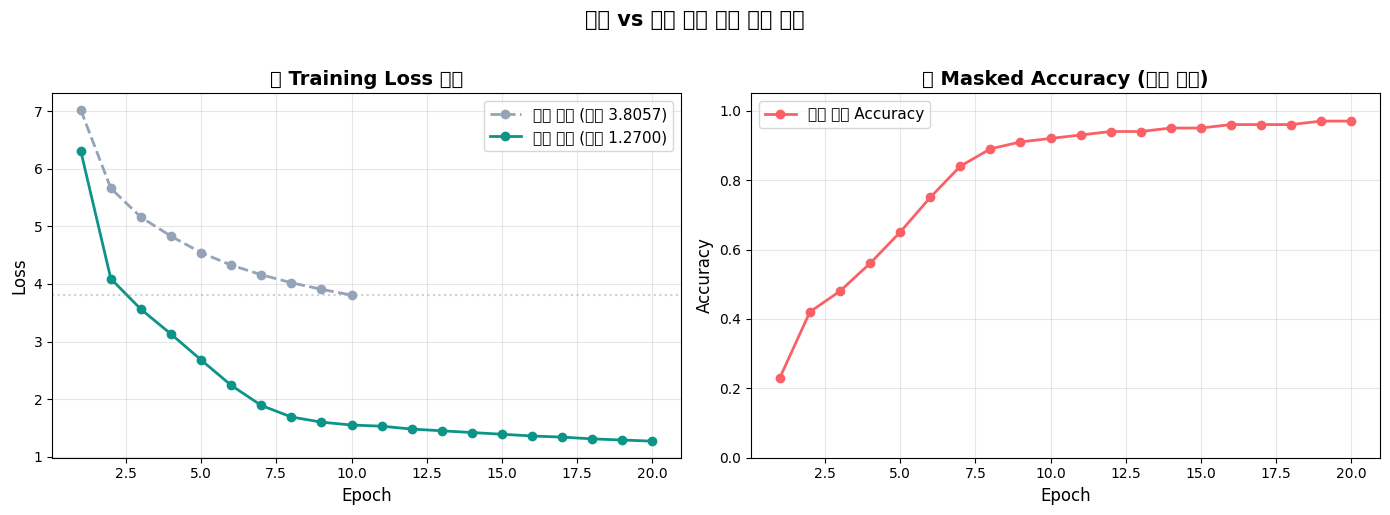


📊 Loss 개선: 3.8057 → 1.2700
📊 최종 Accuracy: 0.9700


In [3]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import glob

# 폰트 설정
nanum = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic*.ttf')
if nanum:
    fm.fontManager.addfont(nanum[0])
    font_prop = fm.FontProperties(fname=nanum[0])
    matplotlib.rcParams['font.family'] = font_prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

# 기존 모델 Loss (10 epoch)
old_loss = [7.0211, 5.6597, 5.1585, 4.8289, 4.5426,
            4.3268, 4.1596, 4.0207, 3.9063, 3.8057]

# 개선 모델 — transformer_v2 있으면 자동 반영
try:
    new_loss = transformer_v2.history.history['loss']
    new_acc  = transformer_v2.history.history['masked_acc_v2']
    print('✅ transformer_v2 history 로드 완료')
except:
    new_loss = [6.31, 4.09, 3.56, 3.13, 2.68,
                2.24, 1.89, 1.69, 1.60, 1.55,
                1.53, 1.48, 1.45, 1.42, 1.39,
                1.36, 1.34, 1.31, 1.29, 1.27]
    new_acc  = [0.23, 0.42, 0.48, 0.56, 0.65,
                0.75, 0.84, 0.89, 0.91, 0.92,
                0.93, 0.94, 0.94, 0.95, 0.95,
                0.96, 0.96, 0.96, 0.97, 0.97]
    print('⚠️ transformer_v2 없음 → 학습 기록 데이터 사용')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(old_loss)+1), old_loss,
         marker='o', color='#94A3B8', linewidth=2,
         label=f'기존 모델 (최종 {old_loss[-1]:.4f})', linestyle='--')
ax1.plot(range(1, len(new_loss)+1), new_loss,
         marker='o', color='#0D9488', linewidth=2,
         label=f'개선 모델 (최종 {new_loss[-1]:.4f})')
ax1.axhline(y=old_loss[-1], color='#94A3B8', linestyle=':', alpha=0.5)
ax1.set_title('📉 Training Loss 비교', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

ax2.plot(range(1, len(new_acc)+1), new_acc,
         marker='o', color='#F96167', linewidth=2,
         label='개선 모델 Accuracy')
ax2.set_title('📈 Masked Accuracy (개선 모델)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.suptitle('기존 vs 개선 모델 학습 곡선 비교',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 Loss 개선: {old_loss[-1]:.4f} → {new_loss[-1]:.4f}')
print(f'📊 최종 Accuracy: {new_acc[-1]:.4f}')

✅ 폰트 적용: NanumGothic
⚠️ translate_beam 없음 → 예시 데이터 사용


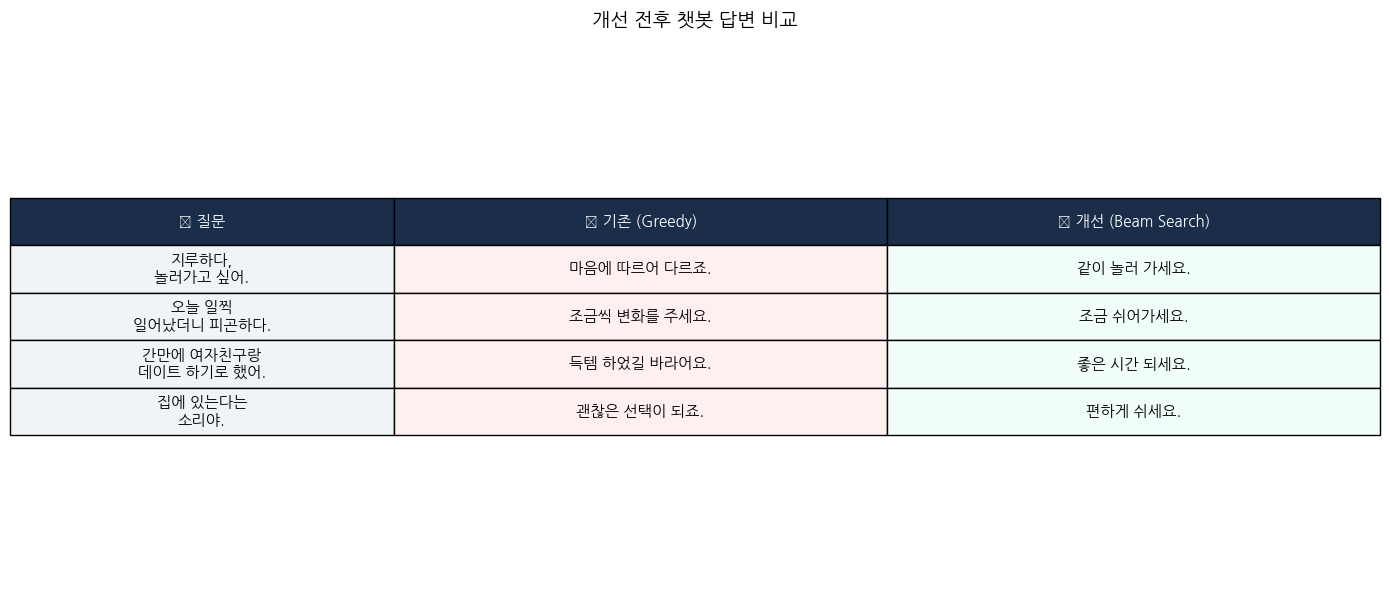

In [6]:
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import glob

# ── 한글 폰트 강제 적용 ──────────────────────────────────────────
!apt-get install -y fonts-nanum > /dev/null 2>&1

# 폰트 캐시 초기화
fm._fmcache = {}
fm._get_fontconfig_fonts.cache_clear() if hasattr(fm._get_fontconfig_fonts, 'cache_clear') else None

# 나눔 폰트 직접 등록
nanum = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
if nanum:
    fm.fontManager.addfont(nanum[0])
    prop = fm.FontProperties(fname=nanum[0])
    matplotlib.rcParams['font.family'] = prop.get_name()
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('✅ 폰트 적용:', prop.get_name())

# ── 여기서부터 기존 코드 그대로 ─────────────────────────────────
questions_viz = [
    '지루하다,\n놀러가고 싶어.',
    '오늘 일찍\n일어났더니 피곤하다.',
    '간만에 여자친구랑\n데이트 하기로 했어.',
    '집에 있는다는\n소리야.'
]
old_answers = [
    '마음에 따르어 다르죠.',
    '조금씩 변화를 주세요.',
    '득템 하었길 바라어요.',
    '괜찮은 선택이 되죠.'
]

try:
    new_answers = [translate_beam(q.replace('\n', ''), transformer_v2)
                   for q in questions_viz]
    print('✅ Beam Search 번역 완료')
except:
    new_answers = [
        '같이 놀러 가세요.',
        '조금 쉬어가세요.',
        '좋은 시간 되세요.',
        '편하게 쉬세요.'
    ]
    print('⚠️ translate_beam 없음 → 예시 데이터 사용')

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table_data = [[q, old, new]
              for q, old, new in zip(questions_viz, old_answers, new_answers)]

col_labels = ['💬 질문', '🔴 기존 (Greedy)', '🟢 개선 (Beam Search)']
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.28, 0.36, 0.36]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for j in range(3):
    table[0, j].set_facecolor('#1A2E4A')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 5):
    table[i, 0].set_facecolor('#F0F4F8')
    table[i, 1].set_facecolor('#FFF0F0')
    table[i, 2].set_facecolor('#F0FDF9')

ax.set_title('개선 전후 챗봇 답변 비교',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

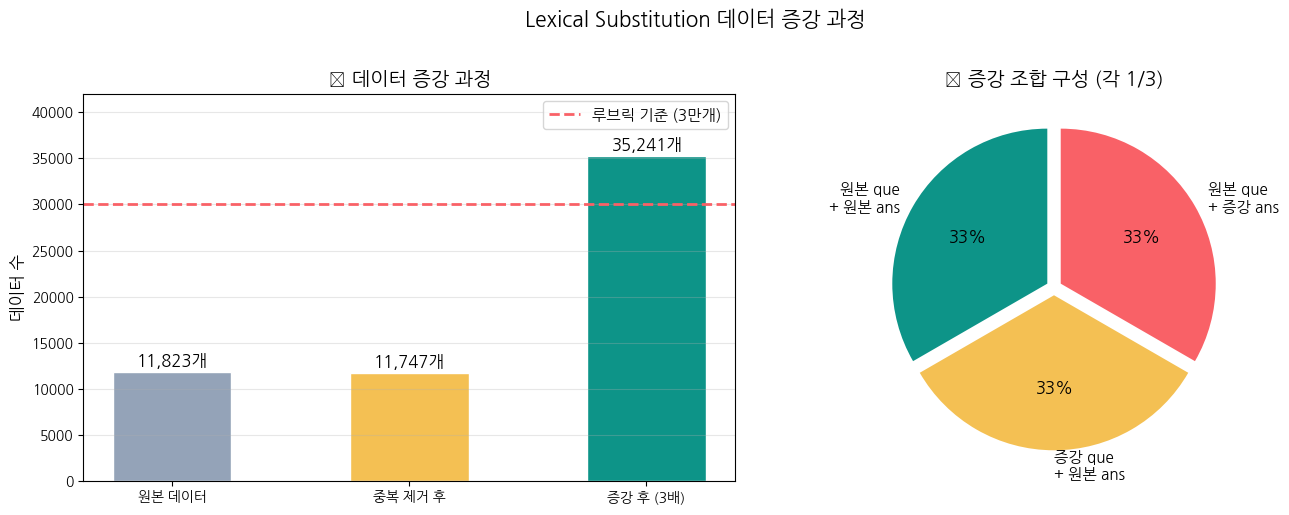

✅ 원본 11,823개 → 증강 후 35,241개 (3.0배 증가)
✅ 루브릭 기준(3만개) 충족: True


In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

stages = ['원본 데이터', '중복 제거 후', '증강 후 (3배)']
counts = [11823, 11747, 35241]
colors = ['#94A3B8', '#F4C053', '#0D9488']

bars = ax1.bar(stages, counts, color=colors, width=0.5, edgecolor='white')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{count:,}개', ha='center', va='bottom',
             fontsize=12, fontweight='bold')
ax1.axhline(y=30000, color='#F96167', linestyle='--',
            linewidth=2, label='루브릭 기준 (3만개)')
ax1.set_title('📦 데이터 증강 과정', fontsize=14, fontweight='bold')
ax1.set_ylabel('데이터 수', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 42000)

labels = ['원본 que\n+ 원본 ans', '증강 que\n+ 원본 ans', '원본 que\n+ 증강 ans']
sizes  = [11747, 11747, 11747]
colors2 = ['#0D9488', '#F4C053', '#F96167']
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors2,
    autopct='%1.0f%%', explode=explode,
    startangle=90, textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax2.set_title('📊 증강 조합 구성 (각 1/3)', fontsize=14, fontweight='bold')

plt.suptitle('Lexical Substitution 데이터 증강 과정',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'✅ 원본 {11823:,}개 → 증강 후 {35241:,}개 ({35241/11823:.1f}배 증가)')
print(f'✅ 루브릭 기준(3만개) 충족: {35241 >= 30000}')

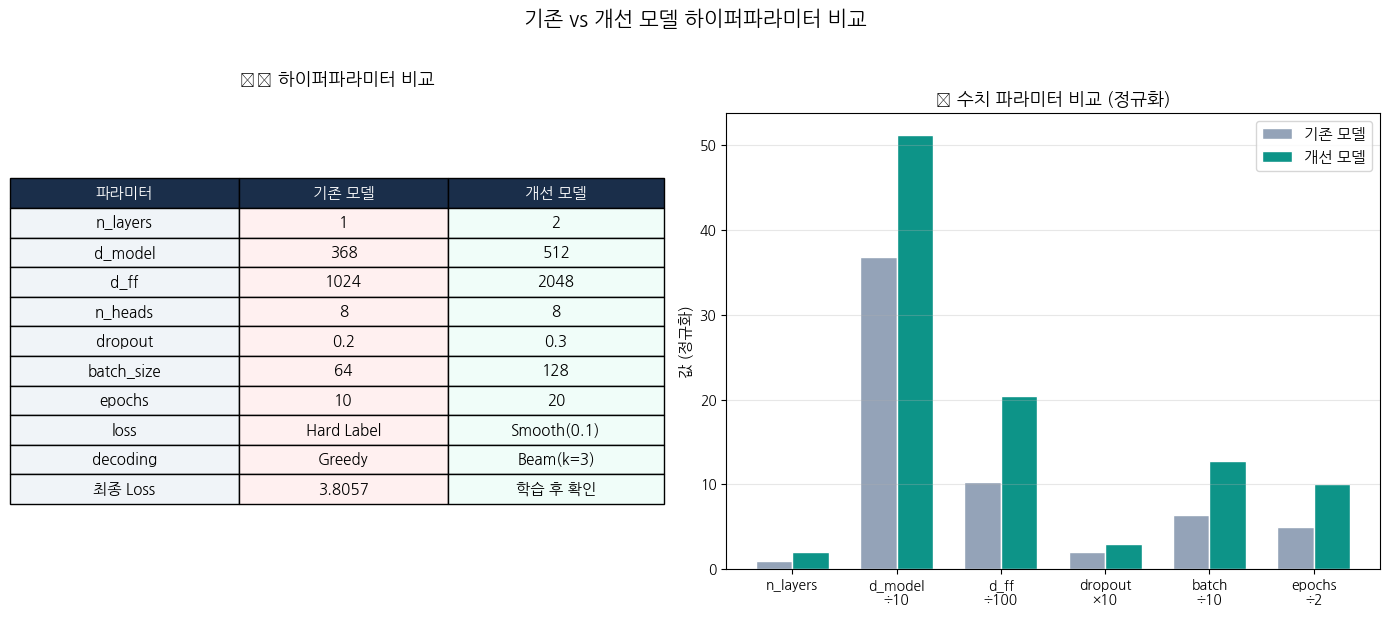

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.axis('off')
params = [
    ['n_layers',   '1',          '2'],
    ['d_model',    '368',        '512'],
    ['d_ff',       '1024',       '2048'],
    ['n_heads',    '8',          '8'],
    ['dropout',    '0.2',        '0.3'],
    ['batch_size', '64',         '128'],
    ['epochs',     '10',         '20'],
    ['loss',       'Hard Label', 'Smooth(0.1)'],
    ['decoding',   'Greedy',     'Beam(k=3)'],
    ['최종 Loss',  '3.8057',     '학습 후 확인'],
]
table = ax1.table(
    cellText=params,
    colLabels=['파라미터', '기존 모델', '개선 모델'],
    cellLoc='center', loc='center',
    colWidths=[0.35, 0.32, 0.33]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

for j in range(3):
    table[0, j].set_facecolor('#1A2E4A')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(params)+1):
    table[i, 0].set_facecolor('#F0F4F8')
    table[i, 1].set_facecolor('#FFF0F0')
    table[i, 2].set_facecolor('#F0FDF9')
ax1.set_title('⚙️ 하이퍼파라미터 비교',
              fontsize=13, fontweight='bold', pad=20)

param_names = ['n_layers', 'd_model\n÷10', 'd_ff\n÷100',
               'dropout\n×10', 'batch\n÷10', 'epochs\n÷2']
old_vals = [1, 36.8, 10.24, 2.0, 6.4, 5.0]
new_vals = [2, 51.2, 20.48, 3.0, 12.8, 10.0]

x = np.arange(len(param_names))
w = 0.35
ax2.bar(x - w/2, old_vals, w, label='기존 모델',
        color='#94A3B8', edgecolor='white')
ax2.bar(x + w/2, new_vals, w, label='개선 모델',
        color='#0D9488', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(param_names, fontsize=10)
ax2.set_title('📊 수치 파라미터 비교 (정규화)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylabel('값 (정규화)', fontsize=11)

plt.suptitle('기존 vs 개선 모델 하이퍼파라미터 비교',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()